# 1 SIDNE Model 2035-2050 
(Spain Industry Decarbonisation with Nuclear Energy) 

This first module focuses in the Chemical Industry decarbonization with SMR-CHP 
(Economic analysis using PyPSA opensource toolbox)

Hypothesis: 
- Demand data from MECs (3% scaled down to spain case;  check calculus [file](https://docs.google.com/spreadsheets/d/1pLw4c-ZX__JsrjUIHaK1mmeCst81JXG1elViPpqSP6U/edit?gid=889823888#gid=889823888))
- Interest Rate Nominal conservative = 8% ([NREL](https://atb.nrel.gov/electricity/2024/data) ATB data)
- SMR costs and efficiencies from [NREL](https://atb.nrel.gov/electricity/2024/data). 
- GAS-CHP costs from [PyPSA 2035](https://github.com/PyPSA/technology-data/blob/master/outputs/costs_2035.csv) and CHP efficiencies from [EPA](https://www.epa.gov/chp/chp-technologies). 


The code is based in: 
- [basic example](https://pypsa.readthedocs.io/en/latest/examples/chp-fixed-heat-power-ratio.html), [Biomass example](https://pypsa.readthedocs.io/en/latest/examples/biomass-synthetic-fuels-carbon-management.html), and [variable heat-power example](https://pypsa.readthedocs.io/en/latest/examples/power-to-gas-boiler-chp.html)
- Previous work developed by Antonio Vaya and Daniel Juiz

In [1]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pypsa
import packages
# conda install openpyxl
# plt.style.use("bmh")
from IPython.display import display, HTML

In [ ]:
# cost=pd.read_excel('./cost_final24.xlsx') #read from an excel to update costs
# csv_file1 = "./cost_final24.csv" # Specify the output CSV file path
# cost.to_csv(csv_file1, index=False) #Save the DataFrame as a CSV file
#-----------
cost=pd.read_csv('./cost_final24.csv', index_col=0) # cost Data Frame

**1.1 Carbon cost & intensity, nuclear taxes and LCOE**
- Select interest rate
- Add Carbon costs updated to 90 USD/MWh, from the 2024 World Energy Outlook [website](https://www.iea.org/reports/world-energy-outlook-2024). 
- Add Carbon intensity values to compute CO2 emissions (already calculated in column carbon_intensity1 of the costs.xml)
- Add Taxes to nuclear energy: taken from PWC'[report](https://www.pwc.es/es/publicaciones/energia/assets/fiscalidad-parque-nuclear.pdf).
- Annualize investment values
- Plot LCOE for Gas_CHP and SMR_CHP technologies

**1.2 Electric prices and tech comparison**

First upload 2023 historical data: profiles, loads and prices
(Source:  [ENTSOE Transparency Platform](https://newtransparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YES-REE------0%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%5B%222024%22%2C%222024%22%5D%2C%22tz%22%3A%22CET%22%7D))


![Alt text](ElectricityPrices23.png)

**1.3 Network & CO2 constraint**

- Stores & DUMP components

- Links

## 0) LCOE como calculo previo

In [9]:
cost=pd.read_csv('./cost_final24.csv', index_col=0) # protección de modificaciones

# ===================== PARÁMETROS DE SENSIBILIDAD Y COSTOS =====================
select_rate = cost.loc["SMR_CHP", "rate"]  # Parámetro de tasa de descuento
cost.loc["Gas_CHP", "carbon_cost"] = 160  # Costo del carbono para Gas_CHP

# Impuestos nucleares en el DataFrame de costos
cost["tax"] = cost["tax"].astype(float)  # Asegura tipo float
cost.loc["SMR_CHP", "tax"] = 16.31  # Impacto de impuestos, 16.31 // Fuente PWC

# ===================== FILTRADO DE RANGO TEMPORAL ==============================
start_time = "2023-01-01 00:00:00"  # Inicio de la simulación
# start_time = "2023-01-02 01:00:00"   # Rango corto para pruebas rápidas
# end_time = "2023-01-02 10:00:00"     # Rango corto para pruebas rápidas
end_time = "2023-12-31 23:00:00"     # Todo el año (8760 horas)
snapshots = pd.date_range(start_time, end_time, freq="h")
num_snapshots = len(snapshots)  # Número de horas simuladas

# ===================== PRECIO DE ELECTRICIDAD ================================
# Carga archivo de precios y lo indexa por fecha/hora
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]

# ===================== DEMANDAS Y ENERGÍA TOTAL ==============================
heat_demand = 294  # MWth
electricity_demand = 135  # MWe
Heat_EnergyT = heat_demand * num_snapshots  # MWh_th totales
PowerT = (heat_demand + electricity_demand)
EnergyT = PowerT * num_snapshots  # MWh totales simulados
NGas_max = Heat_EnergyT / 0.33  # Máximo gas natural requerido

# Actualiza la eficiencia2 en el DataFrame de costes
cost.loc["SMR_CHP", "efficiency2"] = 0.27

# ===================== ANUALIZACIÓN DE COSTOS DE INVERSIÓN =====================
lifetime = cost["lifetime"].values
annualized_inv = [
    packages.annualized(val, select_rate, lifetime[i]) * 1000
    for i, val in enumerate(cost["investment"].values)
]  # Factor 1000 para convertir a USD/MW/año
cost["annualized_investment"] = annualized_inv  # Añade columna al DataFrame

# ===================== CREACIÓN DE LA RED PYPSA ==============================
network = pypsa.Network()  # Crea objeto de red vacío
network.set_snapshots(snapshots)  # Define rango temporal

# ===================== DEFINICIÓN DE CARRIERS Y EMISIONES =====================
network.add("Carrier", "Gas",
            co2_emissions=cost.loc["Gas_CHP", "carbon_intensity"])  # tCO2/MWh_th
network.add("Carrier", "nuclear")
network.add("Carrier", "heat")       # Salida
network.add("Carrier", "electricity")  # Salida

# ===================== RESTRICCIÓN DE CO2 =====================================
# CO2_reduction = 0.2  # Reducción del 80% para 2035
# MaxCO2_possible = cost.loc["Gas_CHP", "carbon_intensity"] * NGas_max  # Máximo evitable
# limit_CO2 = MaxCO2_possible * CO2_reduction  # Límite anual de emisiones
# network.add("GlobalConstraint",
#             "co2_limit",
#             sense="<=",
#             carrier_attribute="co2_emissions",
#             constant=limit_CO2)

# ===================== BUSES PRINCIPALES Y CARGAS =============================
network.add("Bus", "Industry Electricity", carrier="electricity")
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand)
network.add("Bus", "Industry Heat", carrier="heat")
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand)

# ===================== BUSES DE COMBUSTIBLE ===================================
network.add("Bus", "uranium_UO2", carrier="nuclear")
network.add("Bus", "Gas_Fuel_in", carrier="Gas")
network.add("Bus", "Spain_grid", carrier="electricity")

# ===================== ALMACENAMIENTOS (STORES) ===============================
network.add("Store", "Spain gas", bus="Gas_Fuel_in",
    e_initial=1e10,
    e_nom_extendable=True)
network.add("Store", "uranium", bus="uranium_UO2",
    e_initial=1e10,
    e_nom_extendable=True)
network.add("Store", "Spain grid", bus="Spain_grid",
    e_initial=1e10,
    e_nom_extendable=True)

# ===================== DUMP (VERTIDO DE EXCESOS) ==============================
network.add("Bus", "Heat Dump", carrier="heat")
network.add("Link", "Heat_Dump_Link",
    bus0="Industry Heat",
    bus1="Heat Dump",
    p_nom=1e10,
    capital_cost=1,
    marginal_cost=0.1,
    efficiency=1)
network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
    e_initial=0,
    e_nom=1e100)

network.add("Bus", "Electricity Dump", carrier="electricity")
network.add("Link", "Electricity_Dump_Link",
    bus0="Industry Electricity",
    bus1="Electricity Dump",
    p_nom=1e10,
    capital_cost=1,
    marginal_cost=1,
    efficiency=1)
network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
    e_initial=0,
    e_nom=1e100)

# ===================== ENLACES PRINCIPALES (LINKS) ============================
# Gas CHP
network.add("Link", "Link_Gas_CHP",
    bus0="Gas_Fuel_in",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    p_nom_min=0,
    p_nom_max=PowerT*3,
    p_nom_extendable=True,
    capital_cost=cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
    marginal_cost=(cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"] + cost.loc["Gas_CHP", "carbon_cost"] * cost.loc["Gas_CHP", "carbon_intensity"]),
    efficiency=cost.loc["Gas_CHP", "efficiency1"],
    efficiency2=cost.loc["Gas_CHP", "efficiency2"],
)
# SMR CHP
network.add("Link", "Link_SMR_CHP",
    bus0="uranium_UO2",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    p_nom_min=0,
    p_nom_max=PowerT*3,
    p_nom_extendable=True,
    capital_cost=(cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000),
    marginal_cost=(cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]),
    # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], # Alternativa
    efficiency=cost.loc["SMR_CHP", "efficiency1"],
    efficiency2=cost.loc["SMR_CHP", "efficiency2"],
)
# Red eléctrica española
network.add("Link", "Link_Spain_Grid",
    bus0="Spain_grid",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    p_nom=200,
    capital_cost=1,
    marginal_cost=filtered_prices['Price'],  # Precios horarios de 2023
    efficiency=1,
    efficiency2=0,
)

# ===================== OPTIMIZACIÓN Y RESULTADOS ==============================
network.optimize()

# CO2_shadow_price = -network.global_constraints.at["co2_limit", "mu"]
# #print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")
# CO2_shadow_prices.append(CO2_shadow_price)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 11.17it/s]
INFO:linopy.io: Writing time: 2.59s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals
Objective: 1.18e+09
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

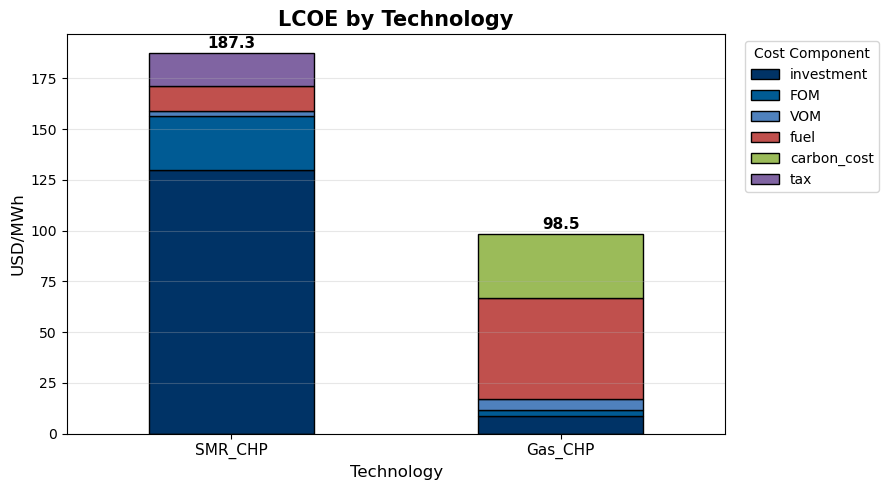

In [10]:
# Calculate LCOE for each technology and cost component
df1 = pd.DataFrame()
techs = ['SMR_CHP', 'Gas_CHP']
for tech in techs:
    df1 = pd.concat([df1, packages.LCOE(tech, cost, tech)])

cost_LCOE = pd.DataFrame()
cost_LCOE['LCOE_Total'] = df1.sum(axis=1)

# Sort and prepare for plotting
df1['Total'] = df1.sum(axis=1)
df1 = df1.sort_values(by='Total', ascending=False)
totals = df1['Total'].copy()  # Save totals for annotation
df1 = df1.drop(columns=['Total'])

engineering_colors = ['#003366', '#005B94', '#4F81BD', '#C0504D', '#9BBB59', '#8064A2']

fig, ax = plt.subplots(figsize=(9, 5))
bars = df1.plot(kind='bar', stacked=True, ax=ax, color=engineering_colors[:len(df1.columns)], edgecolor='black')

ax.set_xlabel('Technology', fontsize=12)
ax.set_ylabel('USD/MWh', fontsize=12)
ax.set_title('LCOE by Technology', fontsize=15, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=11)
ax.legend(title='Cost Component', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Annotate total value on top of each bar
for idx, total in enumerate(totals):
    ax.text(idx, total + 1, f"{total:.1f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

# plt.savefig("LCOE.png", dpi=300, bbox_inches="tight")  # Guardar en PNG (alta resolución, opcional)
plt.show()

## 1.2 Umbral implícito del CO2 (triple escenario)

In [11]:
cost=pd.read_csv('./cost_final24.csv', index_col=0) # protección de modificaciones

# ===================== PARÁMETROS DE SENSIBILIDAD Y COSTOS =====================
select_rate = cost.loc["SMR_CHP", "rate"]  # Parámetro de tasa de descuento
eff2_SMR=cost.loc["SMR_CHP", "efficiency2"]
factors = np.arange(1.0, 2.01, 0.15)
efficiency2_values = [eff2_SMR * f for f in factors]
CO2_shadow_prices = []

# Impuestos nucleares en el DataFrame de costos
cost["tax"] = cost["tax"].astype(float)  # Asegura tipo float
cost.loc["SMR_CHP", "tax"] = 16.31  # Impacto de impuestos, 16.31 // Fuente PWC

# ===================== FILTRADO DE RANGO TEMPORAL ==============================
start_time = "2023-01-01 00:00:00"  # Inicio de la simulación
# start_time = "2023-01-02 01:00:00"   # Rango corto para pruebas rápidas
# end_time = "2023-01-02 10:00:00"     # Rango corto para pruebas rápidas
end_time = "2023-12-31 23:00:00"     # Todo el año (8760 horas)
snapshots = pd.date_range(start_time, end_time, freq="h")
num_snapshots = len(snapshots)  # Número de horas simuladas

# ===================== PRECIO DE ELECTRICIDAD ================================
# Carga archivo de precios y lo indexa por fecha/hora
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]

# ===================== DEMANDAS Y ENERGÍA TOTAL ==============================
heat_demand = 294  # MWth
electricity_demand = 135  # MWe
Heat_EnergyT = heat_demand * num_snapshots  # MWh_th totales
PowerT = (heat_demand + electricity_demand)
EnergyT = PowerT * num_snapshots  # MWh totales simulados
NGas_max = Heat_EnergyT / 0.33  # Máximo gas natural requerido


for eff2 in efficiency2_values:
    # Actualiza la eficiencia2 en el DataFrame de costes
    cost.loc["SMR_CHP", "efficiency2"] = eff2
    
    # ===================== ANUALIZACIÓN DE COSTOS DE INVERSIÓN =====================
    lifetime = cost["lifetime"].values
    annualized_inv = [
        packages.annualized(val, select_rate, lifetime[i]) * 1000
        for i, val in enumerate(cost["investment"].values)
    ]  # Factor 1000 para convertir a USD/MW/año
    cost["annualized_investment"] = annualized_inv  # Añade columna al DataFrame

    # ===================== CREACIÓN DE LA RED PYPSA ==============================
    network = pypsa.Network()  # Crea objeto de red vacío
    network.set_snapshots(snapshots)  # Define rango temporal

    # ===================== DEFINICIÓN DE CARRIERS Y EMISIONES =====================
    network.add("Carrier", "Gas",
                co2_emissions=cost.loc["Gas_CHP", "carbon_intensity"])  # tCO2/MWh_th
    network.add("Carrier", "nuclear")
    network.add("Carrier", "heat")       # Salida
    network.add("Carrier", "electricity")  # Salida

    # ===================== RESTRICCIÓN DE CO2 =====================================
    CO2_reduction = 0.2  # Reducción del 80% para 2035
    MaxCO2_possible = cost.loc["Gas_CHP", "carbon_intensity"] * NGas_max  # Máximo evitable
    limit_CO2 = MaxCO2_possible * CO2_reduction  # Límite anual de emisiones
    network.add("GlobalConstraint",
                "co2_limit",
                sense="<=",
                carrier_attribute="co2_emissions",
                constant=limit_CO2)

    # ===================== BUSES PRINCIPALES Y CARGAS =============================
    network.add("Bus", "Industry Electricity", carrier="electricity")
    network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand)
    network.add("Bus", "Industry Heat", carrier="heat")
    network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand)

    # ===================== BUSES DE COMBUSTIBLE ===================================
    network.add("Bus", "uranium_UO2", carrier="nuclear")
    network.add("Bus", "Gas_Fuel_in", carrier="Gas")
    network.add("Bus", "Spain_grid", carrier="electricity")

    # ===================== ALMACENAMIENTOS (STORES) ===============================
    network.add("Store", "Spain gas", bus="Gas_Fuel_in",
        e_initial=1e10,
        e_nom_extendable=True)
    network.add("Store", "uranium", bus="uranium_UO2",
        e_initial=1e10,
        e_nom_extendable=True)
    network.add("Store", "Spain grid", bus="Spain_grid",
        e_initial=1e10,
        e_nom_extendable=True)

    # ===================== DUMP (VERTIDO DE EXCESOS) ==============================
    network.add("Bus", "Heat Dump", carrier="heat")
    network.add("Link", "Heat_Dump_Link",
        bus0="Industry Heat",
        bus1="Heat Dump",
        p_nom=1e10,
        capital_cost=1,
        marginal_cost=0.1,
        efficiency=1)
    network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
        e_initial=0,
        e_nom=1e100)

    network.add("Bus", "Electricity Dump", carrier="electricity")
    network.add("Link", "Electricity_Dump_Link",
        bus0="Industry Electricity",
        bus1="Electricity Dump",
        p_nom=1e10,
        capital_cost=1,
        marginal_cost=1,
        efficiency=1)
    network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
        e_initial=0,
        e_nom=1e100)

    # ===================== ENLACES PRINCIPALES (LINKS) ============================
    # Gas CHP
    network.add("Link", "Link_Gas_CHP",
        bus0="Gas_Fuel_in",
        bus1="Industry Electricity",
        bus2="Industry Heat",
        p_nom_min=0,
        p_nom_max=PowerT*3,
        p_nom_extendable=True,
        capital_cost=cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
        marginal_cost=(cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"] + cost.loc["Gas_CHP", "carbon_cost"] * cost.loc["Gas_CHP", "carbon_intensity"]),
        efficiency=cost.loc["Gas_CHP", "efficiency1"],
        efficiency2=cost.loc["Gas_CHP", "efficiency2"],
    )
    # SMR CHP
    network.add("Link", "Link_SMR_CHP",
        bus0="uranium_UO2",
        bus1="Industry Electricity",
        bus2="Industry Heat",
        p_nom_min=0,
        p_nom_max=PowerT*3,
        p_nom_extendable=True,
        capital_cost=(cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000),
        marginal_cost=(cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]),
        # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], # Alternativa
        efficiency=cost.loc["SMR_CHP", "efficiency1"],
        efficiency2=cost.loc["SMR_CHP", "efficiency2"],
    )
    # Red eléctrica española
    network.add("Link", "Link_Spain_Grid",
        bus0="Spain_grid",
        bus1="Industry Electricity",
        bus2="Industry Heat",
        p_nom=200,
        capital_cost=1,
        marginal_cost=filtered_prices['Price'],  # Precios horarios de 2023
        efficiency=1,
        efficiency2=0,
    )

    # ===================== OPTIMIZACIÓN Y RESULTADOS ==============================
    network.optimize()

    CO2_shadow_price = -network.global_constraints.at["co2_limit", "mu"]
    #print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")
    CO2_shadow_prices.append(CO2_shadow_price)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 17.32it/s]
INFO:linopy.io: Writing time: 2.78s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals
Objective: 1.46e+09
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 10.41it/s]
INFO:linopy.io: Writing time: 2.77s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals


### 1.1 Resultados del método implícito

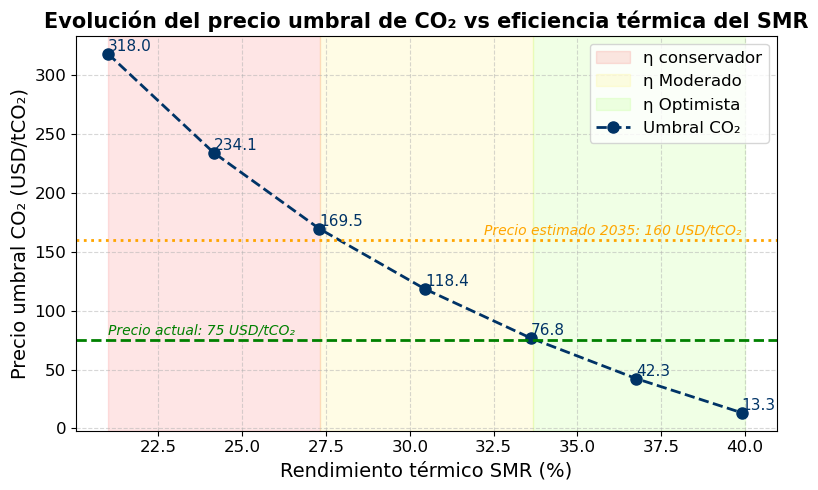

In [12]:
# Crea una tabla resumen con efficiency2 en %
import pandas as pd
# Define reference values for CO2 price (adjust as needed)
ref1 = 75   # Example: current market CO2 price in USD/tCO2
ref2 = 160  # Example: 2035 estimated CO2 price in USD/tCO2

# Multiplica efficiency2_values por 100 para mostrar en %
tabla_resultados = pd.DataFrame({
    "SMR efficiency2 (%)": [e * 100 for e in efficiency2_values],
    "CO2 shadow price (USD/tCO2)": CO2_shadow_prices
})

# Definir los rangos para efficiency2 (%) entre 21% y 40%
min_eff = 21
max_eff = 40
width = (max_eff - min_eff) / 3
rango1 = (min_eff, min_eff + width)      # Conservador
rango2 = (min_eff + width, min_eff + 2*width)  # Moderado
rango3 = (min_eff + 2*width, max_eff)    # optimista

plt.figure(figsize=(8, 5))

# Colorear los rangos de fondo
plt.axvspan(rango1[0], rango1[1], color="#F70000", alpha=0.10, label='η conservador')
plt.axvspan(rango2[0], rango2[1], color="#FFEA00FF", alpha=0.10, label='η Moderado')
plt.axvspan(rango3[0], rango3[1], color="#6FFF00FF", alpha=0.10, label='η Optimista')

plt.plot(
    tabla_resultados["SMR efficiency2 (%)"], 
    tabla_resultados["CO2 shadow price (USD/tCO2)"], 
    marker='o', color='#003366', linewidth=2, markersize=8, linestyle='--', label="Umbral CO₂"
)

# Etiquetas numéricas en cada punto
for x, y in zip(tabla_resultados["SMR efficiency2 (%)"], tabla_resultados["CO2 shadow price (USD/tCO2)"]):
    plt.text(x, y, f"{y:.1f}", fontsize=11, ha='left', va='bottom', color='#003366')

# Añade la línea de referencia del precio actual y coloca el texto en la región izquierda
plt.axhline(ref1, color='green', linestyle='--', linewidth=2)
plt.text(
    tabla_resultados["SMR efficiency2 (%)"].min(), ref1 + 2,
    f'Precio actual: {ref1} USD/tCO₂',
    color='green', fontsize=10, ha='left', va='bottom', fontstyle='italic'
)

# Añade la línea de referencia del precio estimado y coloca el texto en la región derecha
plt.axhline(ref2, color='orange', linestyle=':', linewidth=2)
plt.text(
    tabla_resultados["SMR efficiency2 (%)"].max(), ref2 + 2,
    f'Precio estimado 2035: {ref2} USD/tCO₂',
    color='orange', fontsize=10, ha='right', va='bottom', fontstyle='italic'
)

# Solo la leyenda principal de la línea de umbral CO2 y los rangos de fondo
plt.legend(fontsize=12, loc='best')


plt.xlabel("Rendimiento térmico SMR (%)", fontsize=14)
plt.ylabel("Precio umbral CO₂ (USD/tCO₂)", fontsize=14)
plt.title("Evolución del precio umbral de CO₂ vs eficiencia térmica del SMR", fontsize=15, fontweight='bold')
plt.grid(alpha=0.5, linestyle='--')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
# plt.savefig("CO2_shadow_vs_efficiency2.pdf", bbox_inches="tight")  # Vectorial para LaTeX
# plt.savefig("CO2_shadow_vs_efficiency2.png", dpi=300, bbox_inches="tight")  # PNG alta resolución

## 2. Sensibilidad método explícito
- Explicit: Carbon price Sweep loop 


The previous code (implicit method) finded that the carbon price threshold is near $170$ $USD/tCO_{2}$.

The following code uses the explicit method to check the previous result: it calculates the minimum CO₂ price that makes nuclear enter the market before gas: Perform a sweep of the CO₂ price (e.g., from $50 to $250/tCO₂), and for each value, solve the model and save the resulting nuclear capacity. The minimum price will be the lowest CO₂ value for which nuclear capacity is greater than zero.

In [13]:
cost=pd.read_csv('./cost_final24.csv', index_col=0) # protección de modificaciones

# ===================== PARÁMETROS DE SENSIBILIDAD Y COSTOS =====================
select_rate = cost.loc["SMR_CHP", "rate"]  # Parámetro de tasa de descuento

eff2_SMR=cost.loc["SMR_CHP", "efficiency2"]
factors = np.arange(1.0, 2.01, 0.15)
efficiency2_values = [eff2_SMR * f for f in factors]

nuclear_capacitiesA = []
Gas_capacitiesA = []
resultados_potencias = {} # Diccionario para almacenar potencias de cada iteración

sweep_co2_prices = np.arange(50, 321, 10)  # de 50 a 250 USD/tCO2
Explicit_CO2_shadow_prices = []
Explicit_eff2=[]

# Impuestos nucleares en el DataFrame de costos
cost["tax"] = cost["tax"].astype(float)  # Asegura tipo float
cost.loc["SMR_CHP", "tax"] = 16.31  # Impacto de impuestos, 16.31 // Fuente PWC

# ===================== FILTRADO DE RANGO TEMPORAL ==============================
start_time = "2023-01-01 00:00:00"  # Inicio de la simulación
# start_time = "2023-01-02 01:00:00"   # Rango corto para pruebas rápidas
# end_time = "2023-01-02 10:00:00"     # Rango corto para pruebas rápidas
end_time = "2023-12-31 23:00:00"     # Todo el año (8760 horas)
snapshots = pd.date_range(start_time, end_time, freq="h")
num_snapshots = len(snapshots)  # Número de horas simuladas

# ===================== PRECIO DE ELECTRICIDAD ================================
# Carga archivo de precios y lo indexa por fecha/hora
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]

# ===================== DEMANDAS Y ENERGÍA TOTAL ==============================
heat_demand = 294  # MWth
electricity_demand = 135  # MWe
Heat_EnergyT = heat_demand * num_snapshots  # MWh_th totales
PowerT = (heat_demand + electricity_demand)
EnergyT = PowerT * num_snapshots  # MWh totales simulados
NGas_max = Heat_EnergyT / 0.33  # Máximo gas natural requerido


for eff2 in efficiency2_values:
    # Actualiza la eficiencia2 en el DataFrame de costes
    cost.loc["SMR_CHP", "efficiency2"] = eff2
    
    for price in sweep_co2_prices:
        cost.loc["Gas_CHP", "carbon_cost"] = price
        # ... (reconstruir y resolver el modelo) ...
    
        # ===================== ANUALIZACIÓN DE COSTOS DE INVERSIÓN =====================
        lifetime = cost["lifetime"].values
        annualized_inv = [
            packages.annualized(val, select_rate, lifetime[i]) * 1000
            for i, val in enumerate(cost["investment"].values)
        ]  # Factor 1000 para convertir a USD/MW/año
        cost["annualized_investment"] = annualized_inv  # Añade columna al DataFrame

        # ===================== CREACIÓN DE LA RED PYPSA ==============================
        network = pypsa.Network()  # Crea objeto de red vacío
        network.set_snapshots(snapshots)  # Define rango temporal

        # ===================== DEFINICIÓN DE CARRIERS Y EMISIONES =====================
        network.add("Carrier", "Gas",
                    co2_emissions=cost.loc["Gas_CHP", "carbon_intensity"])  # tCO2/MWh_th
        network.add("Carrier", "nuclear")
        network.add("Carrier", "heat")       # Salida
        network.add("Carrier", "electricity")  # Salida

        # ===================== RESTRICCIÓN DE CO2 =====================================
        # CO2_reduction = 0.2  # Reducción del 80% para 2035
        # MaxCO2_possible = cost.loc["Gas_CHP", "carbon_intensity"] * NGas_max  # Máximo evitable
        # limit_CO2 = MaxCO2_possible * CO2_reduction  # Límite anual de emisiones
        # network.add("GlobalConstraint",
        #             "co2_limit",
        #             sense="<=",
        #             carrier_attribute="co2_emissions",
        #             constant=limit_CO2)

        # ===================== BUSES PRINCIPALES Y CARGAS =============================
        network.add("Bus", "Industry Electricity", carrier="electricity")
        network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand)
        network.add("Bus", "Industry Heat", carrier="heat")
        network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand)

        # ===================== BUSES DE COMBUSTIBLE ===================================
        network.add("Bus", "uranium_UO2", carrier="nuclear")
        network.add("Bus", "Gas_Fuel_in", carrier="Gas")
        network.add("Bus", "Spain_grid", carrier="electricity")

        # ===================== ALMACENAMIENTOS (STORES) ===============================
        network.add("Store", "Spain gas", bus="Gas_Fuel_in",
            e_initial=1e10,
            e_nom_extendable=True)
        network.add("Store", "uranium", bus="uranium_UO2",
            e_initial=1e10,
            e_nom_extendable=True)
        network.add("Store", "Spain grid", bus="Spain_grid",
            e_initial=1e10,
            e_nom_extendable=True)

        # ===================== DUMP (VERTIDO DE EXCESOS) ==============================
        network.add("Bus", "Heat Dump", carrier="heat")
        network.add("Link", "Heat_Dump_Link",
            bus0="Industry Heat",
            bus1="Heat Dump",
            p_nom=1e10,
            capital_cost=1,
            marginal_cost=0.1,
            efficiency=1)
        network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
            e_initial=0,
            e_nom=1e100)

        network.add("Bus", "Electricity Dump", carrier="electricity")
        network.add("Link", "Electricity_Dump_Link",
            bus0="Industry Electricity",
            bus1="Electricity Dump",
            p_nom=1e10,
            capital_cost=1,
            marginal_cost=1,
            efficiency=1)
        network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
            e_initial=0,
            e_nom=1e100)

        # ===================== ENLACES PRINCIPALES (LINKS) ============================
        # Gas CHP
        network.add("Link", "Link_Gas_CHP",
            bus0="Gas_Fuel_in",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom_min=0,
            p_nom_max=PowerT*5,
            p_nom_extendable=True,
            capital_cost=cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
            marginal_cost=(cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"] + cost.loc["Gas_CHP", "carbon_cost"] * cost.loc["Gas_CHP", "carbon_intensity"]),
            efficiency=cost.loc["Gas_CHP", "efficiency1"],
            efficiency2=cost.loc["Gas_CHP", "efficiency2"],
        )
        # SMR CHP
        network.add("Link", "Link_SMR_CHP",
            bus0="uranium_UO2",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom_min=0,
            p_nom_max=PowerT*5,
            p_nom_extendable=True,
            capital_cost=(cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000),
            marginal_cost=(cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]),
            # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], # Alternativa
            efficiency=cost.loc["SMR_CHP", "efficiency1"],
            efficiency2=cost.loc["SMR_CHP", "efficiency2"],
        )
        # Red eléctrica española
        network.add("Link", "Link_Spain_Grid",
            bus0="Spain_grid",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom=200,
            capital_cost=1,
            marginal_cost=filtered_prices['Price'],  # Precios horarios de 2023
            efficiency=1,
            efficiency2=0,
        )

        # ===================== OPTIMIZACIÓN Y RESULTADOS ==============================
        network.optimize()
        
        smr_capacity = network.links.at["Link_SMR_CHP", "p_nom_opt"]
        if smr_capacity != 0:
            Explicit_CO2_shadow_prices.append(price)
            Explicit_eff2.append(eff2 * 100)  # Convertir a porcentaje
            
            nuclear_capacitiesA.append(smr_capacity)
            Gas_capacitiesA.append(network.links.at["Link_Gas_CHP", "p_nom_opt"])
            
            potencias_links = network.links_t.p0.copy()
            # Usa una tupla como clave, por ejemplo (eff2 en %, price)
            resultados_potencias[(eff2 * 100, price)] = potencias_links
            
            break  # Sale del bucle de precios y pasa al siguiente eff2
#-----------

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 14.66it/s]
INFO:linopy.io: Writing time: 2.33s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals
Objective: 9.10e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 14.86it/s]
INFO:linopy.io: Writing time: 2.28s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280327 duals


### 2.1 Resultados método explícito

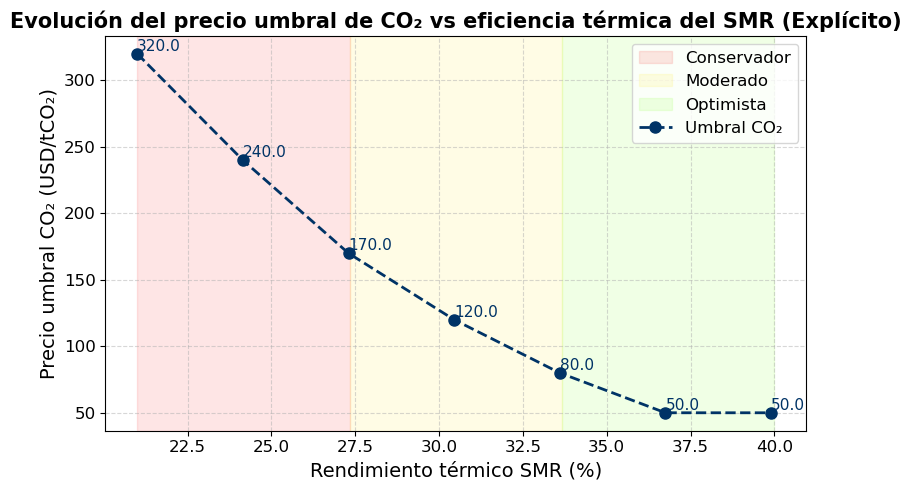

In [14]:
# Comprobar que las listas tienen la misma longitud
if len(Explicit_eff2) != len(Explicit_CO2_shadow_prices):
    print(f"Error: efficiency2_values tiene longitud {len(efficiency2_values)} y Explicit_CO2_shadow_prices tiene longitud {len(Explicit_CO2_shadow_prices)}")
else:
    # Crear DataFrame resumen
    tabla_res_explicit = pd.DataFrame({
        "SMR efficiency2 (%)": Explicit_eff2,
        "CO2 shadow price (USD/tCO2)": Explicit_CO2_shadow_prices
    })

    # Definir los rangos para efficiency2 (%) entre 21% y 40%
    min_eff = 21
    max_eff = 40
    width = (max_eff - min_eff) / 3
    rango1 = (min_eff, min_eff + width)      # Conservador
    rango2 = (min_eff + width, min_eff + 2*width)  # Moderado
    rango3 = (min_eff + 2*width, max_eff)    # optimista

    plt.figure(figsize=(8, 5))

    # Colorear los rangos de fondo
    plt.axvspan(rango1[0], rango1[1], color="#F70000", alpha=0.10, label='Conservador')
    plt.axvspan(rango2[0], rango2[1], color="#FFEA00FF", alpha=0.10, label='Moderado')
    plt.axvspan(rango3[0], rango3[1], color="#6FFF00FF", alpha=0.10, label='Optimista')

    plt.plot(
        tabla_res_explicit["SMR efficiency2 (%)"], 
        tabla_res_explicit["CO2 shadow price (USD/tCO2)"], 
        marker='o', color='#003366', linewidth=2, markersize=8, linestyle='--', label="Umbral CO₂"
    )

    # Etiquetas numéricas en cada punto
    for x, y in zip(tabla_res_explicit["SMR efficiency2 (%)"], tabla_res_explicit["CO2 shadow price (USD/tCO2)"]):
        plt.text(x, y, f"{y:.1f}", fontsize=11, ha='left', va='bottom', color='#003366')

    plt.xlabel("Rendimiento térmico SMR (%)", fontsize=14)
    plt.ylabel("Precio umbral CO₂ (USD/tCO₂)", fontsize=14)
    plt.title("Evolución del precio umbral de CO₂ vs eficiencia térmica del SMR (Explícito)", fontsize=15, fontweight='bold')
    plt.grid(alpha=0.5, linestyle='--')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12, loc='best')
    plt.tight_layout()
    # plt.savefig("CO2_shadow_vs_efficiency2_explicit.pdf", bbox_inches="tight")
    #plt.savefig("CO2_shadow_vs_efficiency2_explicit.png", dpi=300, bbox_inches="tight")
    plt.show()

Debug del código

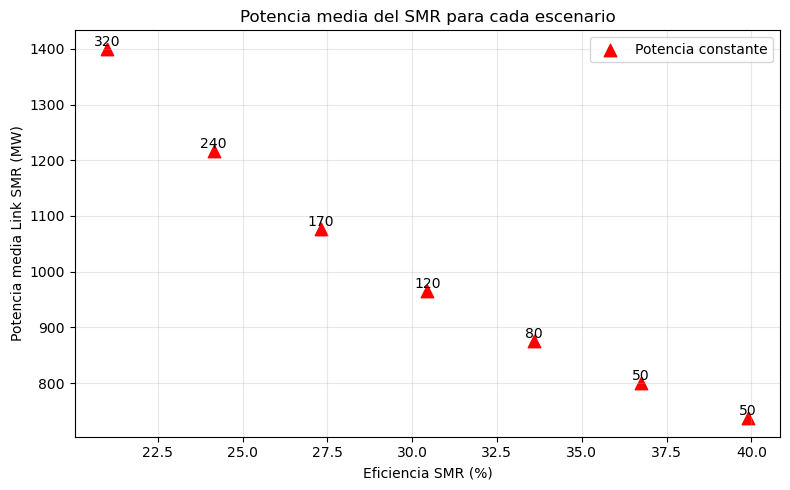

In [15]:
# Supón que resultados_potencias es tu diccionario {(eff2, price): DataFrame}
eff2_list = []
price_list = []
media_potencia = []
constante = []

for (eff2, price), df in resultados_potencias.items():
    serie = df["Link_SMR_CHP"]  # O el link que te interese
    eff2_list.append(eff2)
    price_list.append(price)
    media_potencia.append(serie.mean())
    constante.append(serie.round(6).nunique() == 1)

plt.figure(figsize=(8, 5))
for x, y, is_const, price in zip(eff2_list, media_potencia, constante, price_list):
    if is_const:
        plt.scatter(x, y, marker='^', color='red', s=80, label='Potencia constante' if 'Potencia constante' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(x, y, marker='o', color='blue', s=80, label='Potencia variable' if 'Potencia variable' not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.text(x, y, f"{price}", fontsize=10, ha='center', va='bottom', color='black')  # Etiqueta con el precio de carbono

plt.xlabel("Eficiencia SMR (%)")
plt.ylabel("Potencia media Link SMR (MW)")
plt.title("Potencia media del SMR para cada escenario")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

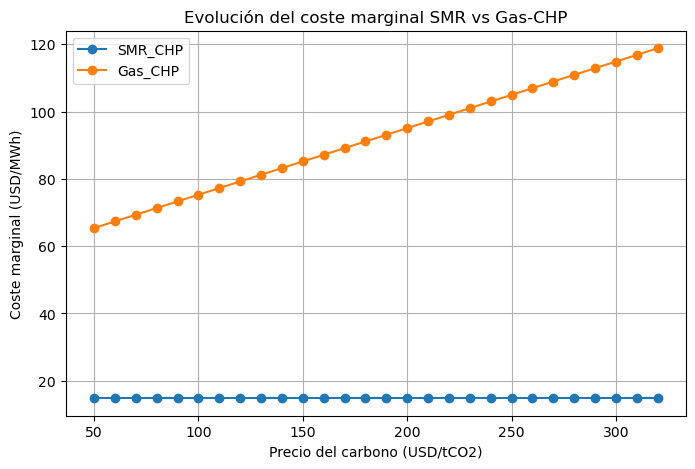

In [16]:
# Calcular y graficar los costes marginales de SMR y GAS_CHP para cada precio de carbono
marginal_cost_smr = []
marginal_cost_gas = []

for price in sweep_co2_prices:
    # Coste marginal SMR (no depende del precio de carbono)
    mc_smr = cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]
    marginal_cost_smr.append(mc_smr)
    # Coste marginal GAS_CHP (sí depende del precio de carbono)
    mc_gas = (cost.loc["Gas_CHP", "VOM"] +
              cost.loc["Gas_CHP", "fuel"] +
              price * cost.loc["Gas_CHP", "carbon_intensity"])
    marginal_cost_gas.append(mc_gas)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(sweep_co2_prices, marginal_cost_smr, label="SMR_CHP", marker='o')
plt.plot(sweep_co2_prices, marginal_cost_gas, label="Gas_CHP", marker='o')
plt.xlabel("Precio del carbono (USD/tCO2)")
plt.ylabel("Coste marginal (USD/MWh)")
plt.title("Evolución del coste marginal SMR vs Gas-CHP")
plt.legend()
plt.grid(True)
plt.show()

## 3) Cappex sweep loop (implicit)
Sensitivity: Explicit CO₂ cost of 100 USD/tCO₂ and varying the SMR capital cost between 3,000 and 20,000 USD/kWe

- Set the CO₂ price at 100 USD/tCO₂.

- Loop over the nuclear capital cost (SMR) in the desired range.

- For each value, update the cost DataFrame, solve the model, and save the nuclear capacity.

In [18]:
cost=pd.read_csv('./cost_final24.csv', index_col=0) # protección de modificaciones

# ===================== PARÁMETROS DE SENSIBILIDAD Y COSTOS =====================
capex_range = np.arange(3000, 15001, 1000)  # de 3000 a 13000 USD/kWe
cost.loc["Gas_CHP", "carbon_cost"] = 0  # nulo--> metodo implicito
nuclear_capacities3 = []

select_rate = cost.loc["SMR_CHP", "rate"]  # Parámetro de tasa de descuento
eff2_SMR=cost.loc["SMR_CHP", "efficiency2"]
factors = np.arange(1.0, 1.21, 0.10) # hasta +20% del valor mínimo (bigotes boxplot)
efficiency2_values = [eff2_SMR * f for f in factors]

CO2_shadow_by_capex = {} # dictionary

# Impuestos nucleares en el DataFrame de costos
cost["tax"] = cost["tax"].astype(float)  # Asegura tipo float
cost.loc["SMR_CHP", "tax"] = 16.31  # Impacto de impuestos, 16.31 // Fuente PWC

# ===================== FILTRADO DE RANGO TEMPORAL ==============================
start_time = "2023-01-01 00:00:00"  # Inicio de la simulación
# start_time = "2023-01-02 01:00:00"   # Rango corto para pruebas rápidas
# end_time = "2023-01-02 10:00:00"     # Rango corto para pruebas rápidas
end_time = "2023-12-31 23:00:00"     # Todo el año (8760 horas)
snapshots = pd.date_range(start_time, end_time, freq="h")
num_snapshots = len(snapshots)  # Número de horas simuladas

# ===================== PRECIO DE ELECTRICIDAD ================================
# Carga archivo de precios y lo indexa por fecha/hora
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]

# ===================== DEMANDAS Y ENERGÍA TOTAL ==============================
heat_demand = 294  # MWth
electricity_demand = 135  # MWe
Heat_EnergyT = heat_demand * num_snapshots  # MWh_th totales
PowerT = (heat_demand + electricity_demand)
EnergyT = PowerT * num_snapshots  # MWh totales simulados
NGas_max = Heat_EnergyT / 0.33  # Máximo gas natural requerido

for capex in capex_range:
    CO2_shadow_prices3 = []
    cost.loc["SMR_CHP", "investment"] = capex
    # ... (recalcula annualized_investment, reconstruye y resuelve el modelo) ...
    
    for eff2 in efficiency2_values:
        # Actualiza la eficiencia2 en el DataFrame de costes
        cost.loc["SMR_CHP", "efficiency2"] = eff2
        
        # ===================== ANUALIZACIÓN DE COSTOS DE INVERSIÓN =====================
        lifetime = cost["lifetime"].values
        annualized_inv = [
            packages.annualized(val, select_rate, lifetime[i]) * 1000
            for i, val in enumerate(cost["investment"].values)
        ]  # Factor 1000 para convertir a USD/MW/año
        cost["annualized_investment"] = annualized_inv  # Añade columna al DataFrame

        # ===================== CREACIÓN DE LA RED PYPSA ==============================
        network = pypsa.Network()  # Crea objeto de red vacío
        network.set_snapshots(snapshots)  # Define rango temporal

        # ===================== DEFINICIÓN DE CARRIERS Y EMISIONES =====================
        network.add("Carrier", "Gas",
                    co2_emissions=cost.loc["Gas_CHP", "carbon_intensity"])  # tCO2/MWh_th
        network.add("Carrier", "nuclear")
        network.add("Carrier", "heat")       # Salida
        network.add("Carrier", "electricity")  # Salida

        # ===================== RESTRICCIÓN DE CO2 =====================================
        CO2_reduction = 0.2  # Reducción del 80% para 2035
        MaxCO2_possible = cost.loc["Gas_CHP", "carbon_intensity"] * NGas_max  # Máximo evitable
        limit_CO2 = MaxCO2_possible * CO2_reduction  # Límite anual de emisiones
        network.add("GlobalConstraint",
                    "co2_limit",
                    sense="<=",
                    carrier_attribute="co2_emissions",
                    constant=limit_CO2)

        # ===================== BUSES PRINCIPALES Y CARGAS =============================
        network.add("Bus", "Industry Electricity", carrier="electricity")
        network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand)
        network.add("Bus", "Industry Heat", carrier="heat")
        network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand)

        # ===================== BUSES DE COMBUSTIBLE ===================================
        network.add("Bus", "uranium_UO2", carrier="nuclear")
        network.add("Bus", "Gas_Fuel_in", carrier="Gas")
        network.add("Bus", "Spain_grid", carrier="electricity")

        # ===================== ALMACENAMIENTOS (STORES) ===============================
        network.add("Store", "Spain gas", bus="Gas_Fuel_in",
            e_initial=1e10,
            e_nom_extendable=True)
        network.add("Store", "uranium", bus="uranium_UO2",
            e_initial=1e10,
            e_nom_extendable=True)
        network.add("Store", "Spain grid", bus="Spain_grid",
            e_initial=1e10,
            e_nom_extendable=True)

        # ===================== DUMP (VERTIDO DE EXCESOS) ==============================
        network.add("Bus", "Heat Dump", carrier="heat")
        network.add("Link", "Heat_Dump_Link",
            bus0="Industry Heat",
            bus1="Heat Dump",
            p_nom=1e10,
            capital_cost=1,
            marginal_cost=0.1,
            efficiency=1)
        network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
            e_initial=0,
            e_nom=1e100)

        network.add("Bus", "Electricity Dump", carrier="electricity")
        network.add("Link", "Electricity_Dump_Link",
            bus0="Industry Electricity",
            bus1="Electricity Dump",
            p_nom=1e10,
            capital_cost=1,
            marginal_cost=1,
            efficiency=1)
        network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
            e_initial=0,
            e_nom=1e100)

        # ===================== ENLACES PRINCIPALES (LINKS) ============================
        # Gas CHP
        network.add("Link", "Link_Gas_CHP",
            bus0="Gas_Fuel_in",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom_min=0,
            p_nom_max=PowerT*3,
            p_nom_extendable=True,
            capital_cost=cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
            marginal_cost=(cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"] + cost.loc["Gas_CHP", "carbon_cost"] * cost.loc["Gas_CHP", "carbon_intensity"]),
            efficiency=cost.loc["Gas_CHP", "efficiency1"],
            efficiency2=cost.loc["Gas_CHP", "efficiency2"],
        )
        # SMR CHP
        network.add("Link", "Link_SMR_CHP",
            bus0="uranium_UO2",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom_min=0,
            p_nom_max=PowerT*3,
            p_nom_extendable=True,
            capital_cost=(cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000),
            marginal_cost=(cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]),
            # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], # Alternativa
            efficiency=cost.loc["SMR_CHP", "efficiency1"],
            efficiency2=cost.loc["SMR_CHP", "efficiency2"],
        )
        # Red eléctrica española
        network.add("Link", "Link_Spain_Grid",
            bus0="Spain_grid",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom=200,
            capital_cost=1,
            marginal_cost=filtered_prices['Price'],  # Precios horarios de 2023
            efficiency=1,
            efficiency2=0,
        )

        # ===================== OPTIMIZACIÓN Y RESULTADOS ==============================
        network.optimize()

        CO2_shadow_price3 = -network.global_constraints.at["co2_limit", "mu"]
        #print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")
        CO2_shadow_prices3.append(CO2_shadow_price3)
    CO2_shadow_by_capex[capex] = CO2_shadow_prices3

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00,  7.02it/s]
INFO:linopy.io: Writing time: 5.25s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals
Objective: 8.21e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 12.82it/s]
INFO:linopy.io: Writing time: 2.34s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals


### 3.1 Resultados Boxplot Capex-SMR

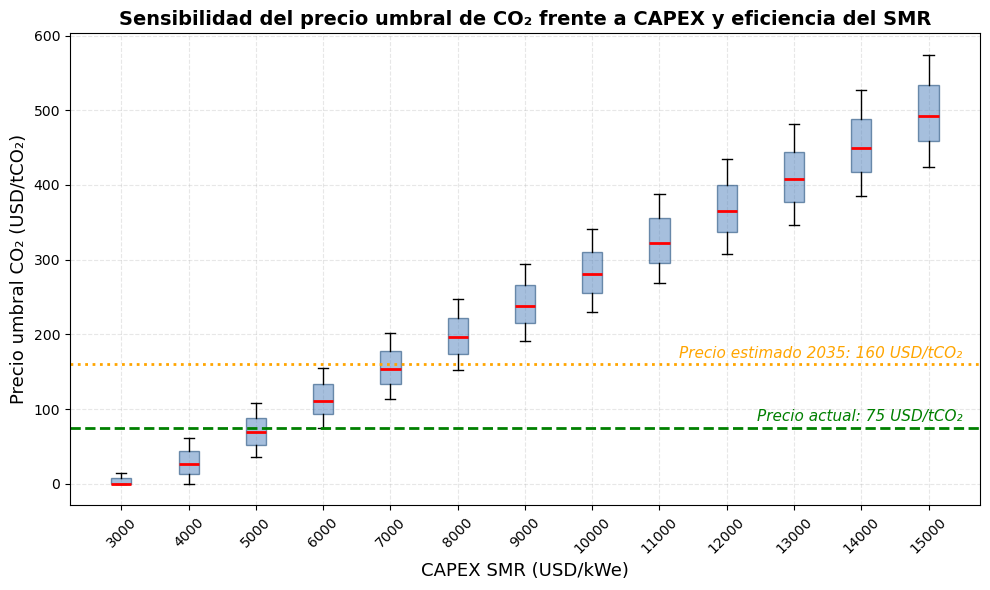

In [ ]:
# Prepara los datos para el boxplot
capex_sorted = sorted(CO2_shadow_by_capex.keys())
data_boxplot = [CO2_shadow_by_capex[c] for c in capex_sorted]

plt.figure(figsize=(10, 6))
plt.boxplot(
    data_boxplot,
    positions=capex_sorted,
    widths=300,
    patch_artist=True,
    boxprops=dict(facecolor='#4F81BD', color='#003366', alpha=0.5),
    medianprops=dict(color='red', linewidth=2)
)

# Añade líneas de referencia y coloca las leyendas cerca de las líneas, optimizando el espacio
plt.axhline(ref1, color='green', linestyle='--', linewidth=2)
plt.text(
    capex_sorted[-1] + 500, ref1 + 5,f'Precio actual: {ref1} USD/tCO₂',
    color='green', fontsize=11, ha='right', va='bottom', fontstyle='italic',
    bbox=dict(facecolor='white', alpha=0, edgecolor='none')
)

plt.axhline(ref2, color='orange', linestyle=':', linewidth=2)
plt.text(
    capex_sorted[-1] + 500, ref2 + 5,f'Precio estimado 2035: {ref2} USD/tCO₂',
    color='orange', fontsize=11, ha='right', va='bottom', fontstyle='italic',
    bbox=dict(facecolor='white', alpha=0, edgecolor='none')
)

plt.xlabel("CAPEX SMR (USD/kWe)", fontsize=13)
plt.ylabel("Precio umbral CO₂ (USD/tCO₂)", fontsize=13)
plt.title("Sensibilidad del precio umbral de CO₂ frente a CAPEX y eficiencia del SMR", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.xticks(capex_sorted, rotation=45)
plt.tight_layout()
# plt.savefig("Capex_sensitivity.png", dpi=300, bbox_inches="tight")

plt.show()

Resultados

## 4 Precio del Gas (Explícito)

In [ ]:
cost=pd.read_csv('./cost_final24.csv', index_col=0) # protección de modificaciones

# ===================== PARÁMETROS DE SENSIBILIDAD Y COSTOS =====================
GasFuel_range = np.arange(10, 51, 5)  # de 3000 a 13000 USD/kWe
cost.loc["Gas_CHP", "carbon_cost"] = 0  # nulo--> metodo implicito
nuclear_capacities3 = []

select_rate = cost.loc["SMR_CHP", "rate"]  # Parámetro de tasa de descuento
eff2_SMR=cost.loc["SMR_CHP", "efficiency2"]
factors = np.arange(1.0, 1.21, 0.10) # hasta +20% del valor mínimo (bigotes boxplot)
efficiency2_values = [eff2_SMR * f for f in factors]

CO2_shadow_by_GasFuel = {} # dictionary

# Impuestos nucleares en el DataFrame de costos
cost["tax"] = cost["tax"].astype(float)  # Asegura tipo float
cost.loc["SMR_CHP", "tax"] = 16.31  # Impacto de impuestos, 16.31 // Fuente PWC

# ===================== FILTRADO DE RANGO TEMPORAL ==============================
start_time = "2023-01-01 00:00:00"  # Inicio de la simulación
# start_time = "2023-01-02 01:00:00"   # Rango corto para pruebas rápidas
# end_time = "2023-01-02 10:00:00"     # Rango corto para pruebas rápidas
end_time = "2023-12-31 23:00:00"     # Todo el año (8760 horas)
snapshots = pd.date_range(start_time, end_time, freq="h")
num_snapshots = len(snapshots)  # Número de horas simuladas

# ===================== PRECIO DE ELECTRICIDAD ================================
# Carga archivo de precios y lo indexa por fecha/hora
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]

# ===================== DEMANDAS Y ENERGÍA TOTAL ==============================
heat_demand = 294  # MWth
electricity_demand = 135  # MWe
Heat_EnergyT = heat_demand * num_snapshots  # MWh_th totales
PowerT = (heat_demand + electricity_demand)
EnergyT = PowerT * num_snapshots  # MWh totales simulados
NGas_max = Heat_EnergyT / 0.33  # Máximo gas natural requerido

for GasFuel in GasFuel_range:
    CO2_shadow_prices4 = []
    cost.loc["Gas_CHP", "fuel"] = GasFuel
    # ... (recalcula annualized_investment, reconstruye y resuelve el modelo) ...
    
    for eff2 in efficiency2_values:
        # Actualiza la eficiencia2 en el DataFrame de costes
        cost.loc["SMR_CHP", "efficiency2"] = eff2
        
        # ===================== ANUALIZACIÓN DE COSTOS DE INVERSIÓN =====================
        lifetime = cost["lifetime"].values
        annualized_inv = [
            packages.annualized(val, select_rate, lifetime[i]) * 1000
            for i, val in enumerate(cost["investment"].values)
        ]  # Factor 1000 para convertir a USD/MW/año
        cost["annualized_investment"] = annualized_inv  # Añade columna al DataFrame

        # ===================== CREACIÓN DE LA RED PYPSA ==============================
        network = pypsa.Network()  # Crea objeto de red vacío
        network.set_snapshots(snapshots)  # Define rango temporal

        # ===================== DEFINICIÓN DE CARRIERS Y EMISIONES =====================
        network.add("Carrier", "Gas",
                    co2_emissions=cost.loc["Gas_CHP", "carbon_intensity"])  # tCO2/MWh_th
        network.add("Carrier", "nuclear")
        network.add("Carrier", "heat")       # Salida
        network.add("Carrier", "electricity")  # Salida

        # ===================== RESTRICCIÓN DE CO2 =====================================
        CO2_reduction = 0.2  # Reducción del 80% para 2035
        MaxCO2_possible = cost.loc["Gas_CHP", "carbon_intensity"] * NGas_max  # Máximo evitable
        limit_CO2 = MaxCO2_possible * CO2_reduction  # Límite anual de emisiones
        network.add("GlobalConstraint",
                    "co2_limit",
                    sense="<=",
                    carrier_attribute="co2_emissions",
                    constant=limit_CO2)

        # ===================== BUSES PRINCIPALES Y CARGAS =============================
        network.add("Bus", "Industry Electricity", carrier="electricity")
        network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand)
        network.add("Bus", "Industry Heat", carrier="heat")
        network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand)

        # ===================== BUSES DE COMBUSTIBLE ===================================
        network.add("Bus", "uranium_UO2", carrier="nuclear")
        network.add("Bus", "Gas_Fuel_in", carrier="Gas")
        network.add("Bus", "Spain_grid", carrier="electricity")

        # ===================== ALMACENAMIENTOS (STORES) ===============================
        network.add("Store", "Spain gas", bus="Gas_Fuel_in",
            e_initial=1e10,
            e_nom_extendable=True)
        network.add("Store", "uranium", bus="uranium_UO2",
            e_initial=1e10,
            e_nom_extendable=True)
        network.add("Store", "Spain grid", bus="Spain_grid",
            e_initial=1e10,
            e_nom_extendable=True)

        # ===================== DUMP (VERTIDO DE EXCESOS) ==============================
        network.add("Bus", "Heat Dump", carrier="heat")
        network.add("Link", "Heat_Dump_Link",
            bus0="Industry Heat",
            bus1="Heat Dump",
            p_nom=1e10,
            capital_cost=1,
            marginal_cost=0.1,
            efficiency=1)
        network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
            e_initial=0,
            e_nom=1e100)

        network.add("Bus", "Electricity Dump", carrier="electricity")
        network.add("Link", "Electricity_Dump_Link",
            bus0="Industry Electricity",
            bus1="Electricity Dump",
            p_nom=1e10,
            capital_cost=1,
            marginal_cost=1,
            efficiency=1)
        network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
            e_initial=0,
            e_nom=1e100)

        # ===================== ENLACES PRINCIPALES (LINKS) ============================
        # Gas CHP
        network.add("Link", "Link_Gas_CHP",
            bus0="Gas_Fuel_in",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom_min=0,
            p_nom_max=PowerT*3,
            p_nom_extendable=True,
            capital_cost=cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
            marginal_cost=(cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"] + cost.loc["Gas_CHP", "carbon_cost"] * cost.loc["Gas_CHP", "carbon_intensity"]),
            efficiency=cost.loc["Gas_CHP", "efficiency1"],
            efficiency2=cost.loc["Gas_CHP", "efficiency2"],
        )
        # SMR CHP
        network.add("Link", "Link_SMR_CHP",
            bus0="uranium_UO2",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom_min=0,
            p_nom_max=PowerT*3,
            p_nom_extendable=True,
            capital_cost=(cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000),
            marginal_cost=(cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]),
            # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], # Alternativa
            efficiency=cost.loc["SMR_CHP", "efficiency1"],
            efficiency2=cost.loc["SMR_CHP", "efficiency2"],
        )
        # Red eléctrica española
        network.add("Link", "Link_Spain_Grid",
            bus0="Spain_grid",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom=200,
            capital_cost=1,
            marginal_cost=filtered_prices['Price'],  # Precios horarios de 2023
            efficiency=1,
            efficiency2=0,
        )

        # ===================== OPTIMIZACIÓN Y RESULTADOS ==============================
        network.optimize()

        CO2_shadow_price4 = -network.global_constraints.at["co2_limit", "mu"]
        #print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")
        CO2_shadow_prices4.append(CO2_shadow_price4)
    CO2_shadow_by_GasFuel[GasFuel] = CO2_shadow_prices4

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 14.43it/s]
INFO:linopy.io: Writing time: 2.49s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals
Objective: 1.40e+09
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00,  7.19it/s]
INFO:linopy.io: Writing time: 3.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals


### 4.1 Resultados boxplot

Marcar la eficiencia base y añadir valores de referencia en el boxplot:

- Marcar eficiencia base: Calcula el índice de la eficiencia base en tu lista efficiency2_values.
Dibuja los valores correspondientes como puntos destacados sobre cada caja del boxplot.
- Añade líneas de referencia: Usa plt.axhline() para añadir líneas horizontales con el valor de referencia que desees (por ejemplo, un precio de CO₂ típico de mercado o un objetivo político).

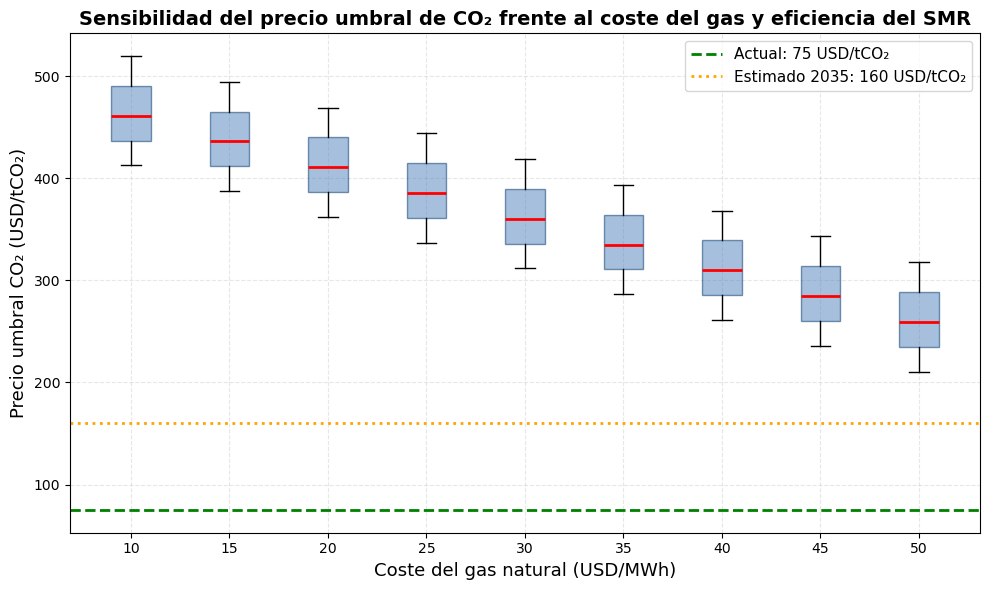

In [ ]:
import matplotlib.pyplot as plt

gas_sorted = sorted(CO2_shadow_by_GasFuel.keys())
data_boxplot = [CO2_shadow_by_GasFuel[g] for g in gas_sorted]

# Valores de referencia (puedes cambiar estos valores)
ref1 = 75  # Ejemplo: precio de CO2 de mercado
ref2 = 160  # Ejemplo: objetivo político

plt.figure(figsize=(10, 6))
bp = plt.boxplot(
    data_boxplot,
    positions=gas_sorted,
    widths=2,
    patch_artist=True,
    boxprops=dict(facecolor='#4F81BD', color='#003366', alpha=0.5),
    medianprops=dict(color='red', linewidth=2)
)

# Añade líneas de referencia y coloca las leyendas cerca de las líneas, optimizando el espacio
plt.axhline(ref1, color='green', linestyle='--', linewidth=2)
plt.text(
    capex_sorted[-1] + 500, ref1 + 5,f'Precio actual: {ref1} USD/tCO₂',
    color='green', fontsize=11, ha='right', va='bottom', fontstyle='italic',
    bbox=dict(facecolor='white', alpha=0, edgecolor='none')
)

plt.axhline(ref2, color='orange', linestyle=':', linewidth=2)
plt.text(
    capex_sorted[-1] + 500, ref2 + 5,f'Precio estimado 2035: {ref2} USD/tCO₂',
    color='orange', fontsize=11, ha='right', va='bottom', fontstyle='italic',
    bbox=dict(facecolor='white', alpha=0, edgecolor='none')
)

plt.xlabel("Coste del gas natural (USD/MWh)", fontsize=13)
plt.ylabel("Precio umbral CO₂ (USD/tCO₂)", fontsize=13)
plt.title("Sensibilidad del precio umbral de CO₂ frente al coste del gas y eficiencia del SMR", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.xticks(gas_sorted)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("GasFuel.png", dpi=300, bbox_inches="tight")

plt.show()


## 5) Heatmap Capex-Gas-CO2-SMR

En este heatmap se fija un rendimiento térmico conservador de 27% para el SMR. Y se grafica el valor umbral del CO2 implícito teniendo para cada pareja de capex-SMR y precio de Gas natural en los siguientes rangos: 
- SMR-Capex: 3000 a 15000 (USD/kWe)
- Coste del gas natural: 10 a 50 (USD/MWh)

In [29]:
cost = pd.read_csv('./cost_final24.csv', index_col=0)

# Parámetros
capex_range = np.arange(3000, 16001, 1000)  # CAPEX range
GasFuel_range = np.arange(10, 51, 5)           # Coste del gas
eff2_SMR = 0.27                            # Eficiencia fija SMR en 27%
cost.loc["SMR_CHP", "efficiency2"] = eff2_SMR

# Diccionario o matriz para guardar resultados
# Usaremos un DataFrame para construir el heatmap
df_results = pd.DataFrame(index=GasFuel_range, columns=capex_range)

select_rate = cost.loc["SMR_CHP", "rate"]
# Ajusta si tienes que fijar carbon_cost en 0 (método implícito):
cost.loc["Gas_CHP", "carbon_cost"] = 0

# Impuestos nucleares en el DataFrame de costos
cost["tax"] = cost["tax"].astype(float)  # Asegura tipo float
cost.loc["SMR_CHP", "tax"] = 16.31  # Impacto de impuestos, 16.31 // Fuente PWC

# ===================== FILTRADO DE RANGO TEMPORAL ==============================
start_time = "2023-01-01 00:00:00"  # Inicio de la simulación
# start_time = "2023-01-02 01:00:00"   # Rango corto para pruebas rápidas
# end_time = "2023-01-02 10:00:00"     # Rango corto para pruebas rápidas
end_time = "2023-12-31 23:00:00"     # Todo el año (8760 horas)
snapshots = pd.date_range(start_time, end_time, freq="h")
num_snapshots = len(snapshots)  # Número de horas simuladas

# ===================== PRECIO DE ELECTRICIDAD ================================
# Carga archivo de precios y lo indexa por fecha/hora
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]

# ===================== DEMANDAS Y ENERGÍA TOTAL ==============================
heat_demand = 294  # MWth
electricity_demand = 135  # MWe
Heat_EnergyT = heat_demand * num_snapshots  # MWh_th totales
PowerT = (heat_demand + electricity_demand)
EnergyT = PowerT * num_snapshots  # MWh totales simulados
NGas_max = Heat_EnergyT / 0.33  # Máximo gas natural requerido

for capex in capex_range:
    for gas_price in GasFuel_range:
        # CO2_shadow_prices5 = []
        # 1) Fija CAPEX del SMR
        cost.loc["SMR_CHP", "investment"] = capex
        # 2) Fija coste combustible Gas
        cost.loc["Gas_CHP", "fuel"] = gas_price

        # ===================== ANUALIZACIÓN DE COSTOS DE INVERSIÓN =====================
        lifetime = cost["lifetime"].values
        annualized_inv = [
            packages.annualized(val, select_rate, lifetime[i]) * 1000
            for i, val in enumerate(cost["investment"].values)
        ]  # Factor 1000 para convertir a USD/MW/año
        cost["annualized_investment"] = annualized_inv  # Añade columna al DataFrame

        # ===================== CREACIÓN DE LA RED PYPSA ==============================
        network = pypsa.Network()  # Crea objeto de red vacío
        network.set_snapshots(snapshots)  # Define rango temporal

        # ===================== DEFINICIÓN DE CARRIERS Y EMISIONES =====================
        network.add("Carrier", "Gas",
                    co2_emissions=cost.loc["Gas_CHP", "carbon_intensity"])  # tCO2/MWh_th
        network.add("Carrier", "nuclear")
        network.add("Carrier", "heat")       # Salida
        network.add("Carrier", "electricity")  # Salida

        # ===================== RESTRICCIÓN DE CO2 =====================================
        CO2_reduction = 0.2  # Reducción del 80% para 2035
        MaxCO2_possible = cost.loc["Gas_CHP", "carbon_intensity"] * NGas_max  # Máximo evitable
        limit_CO2 = MaxCO2_possible * CO2_reduction  # Límite anual de emisiones
        network.add("GlobalConstraint",
                    "co2_limit",
                    sense="<=",
                    carrier_attribute="co2_emissions",
                    constant=limit_CO2)

        # ===================== BUSES PRINCIPALES Y CARGAS =============================
        network.add("Bus", "Industry Electricity", carrier="electricity")
        network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand)
        network.add("Bus", "Industry Heat", carrier="heat")
        network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand)

        # ===================== BUSES DE COMBUSTIBLE ===================================
        network.add("Bus", "uranium_UO2", carrier="nuclear")
        network.add("Bus", "Gas_Fuel_in", carrier="Gas")
        network.add("Bus", "Spain_grid", carrier="electricity")

        # ===================== ALMACENAMIENTOS (STORES) ===============================
        network.add("Store", "Spain gas", bus="Gas_Fuel_in",
            e_initial=1e10,
            e_nom_extendable=True)
        network.add("Store", "uranium", bus="uranium_UO2",
            e_initial=1e10,
            e_nom_extendable=True)
        network.add("Store", "Spain grid", bus="Spain_grid",
            e_initial=1e10,
            e_nom_extendable=True)

        # ===================== DUMP (VERTIDO DE EXCESOS) ==============================
        network.add("Bus", "Heat Dump", carrier="heat")
        network.add("Link", "Heat_Dump_Link",
            bus0="Industry Heat",
            bus1="Heat Dump",
            p_nom=1e10,
            capital_cost=1,
            marginal_cost=0.1,
            efficiency=1)
        network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
            e_initial=0,
            e_nom=1e100)

        network.add("Bus", "Electricity Dump", carrier="electricity")
        network.add("Link", "Electricity_Dump_Link",
            bus0="Industry Electricity",
            bus1="Electricity Dump",
            p_nom=1e10,
            capital_cost=1,
            marginal_cost=1,
            efficiency=1)
        network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
            e_initial=0,
            e_nom=1e100)

        # ===================== ENLACES PRINCIPALES (LINKS) ============================
        # Gas CHP
        network.add("Link", "Link_Gas_CHP",
            bus0="Gas_Fuel_in",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom_min=0,
            p_nom_max=PowerT*3,
            p_nom_extendable=True,
            capital_cost=cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
            marginal_cost=(cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"] + cost.loc["Gas_CHP", "carbon_cost"] * cost.loc["Gas_CHP", "carbon_intensity"]),
            efficiency=cost.loc["Gas_CHP", "efficiency1"],
            efficiency2=cost.loc["Gas_CHP", "efficiency2"],
        )
        # SMR CHP
        network.add("Link", "Link_SMR_CHP",
            bus0="uranium_UO2",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom_min=0,
            p_nom_max=PowerT*3,
            p_nom_extendable=True,
            capital_cost=(cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000),
            marginal_cost=(cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]),
            # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], # Alternativa
            efficiency=cost.loc["SMR_CHP", "efficiency1"],
            efficiency2=cost.loc["SMR_CHP", "efficiency2"],
        )
        # Red eléctrica española
        network.add("Link", "Link_Spain_Grid",
            bus0="Spain_grid",
            bus1="Industry Electricity",
            bus2="Industry Heat",
            p_nom=200,
            capital_cost=1,
            marginal_cost=filtered_prices['Price'],  # Precios horarios de 2023
            efficiency=1,
            efficiency2=0,
        )

        # ===================== OPTIMIZACIÓN Y RESULTADOS ==============================
        network.optimize()

        CO2_shadow_price5 = -network.global_constraints.at["co2_limit", "mu"]
        #print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")

        # Guarda el resultado en el DataFrame
        df_results.loc[gas_price, capex] = CO2_shadow_price5

# Con df_results tienes un DataFrame 2D con índices=gas, columnas=capex
# Para el heatmap, conviene convertir a float
df_results = df_results.astype(float)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 12.70it/s]
INFO:linopy.io: Writing time: 2.44s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals
Objective: 5.98e+08
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 13.92it/s]
INFO:linopy.io: Writing time: 2.34s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131405 primals, 280328 duals


### 5.1 Resultados

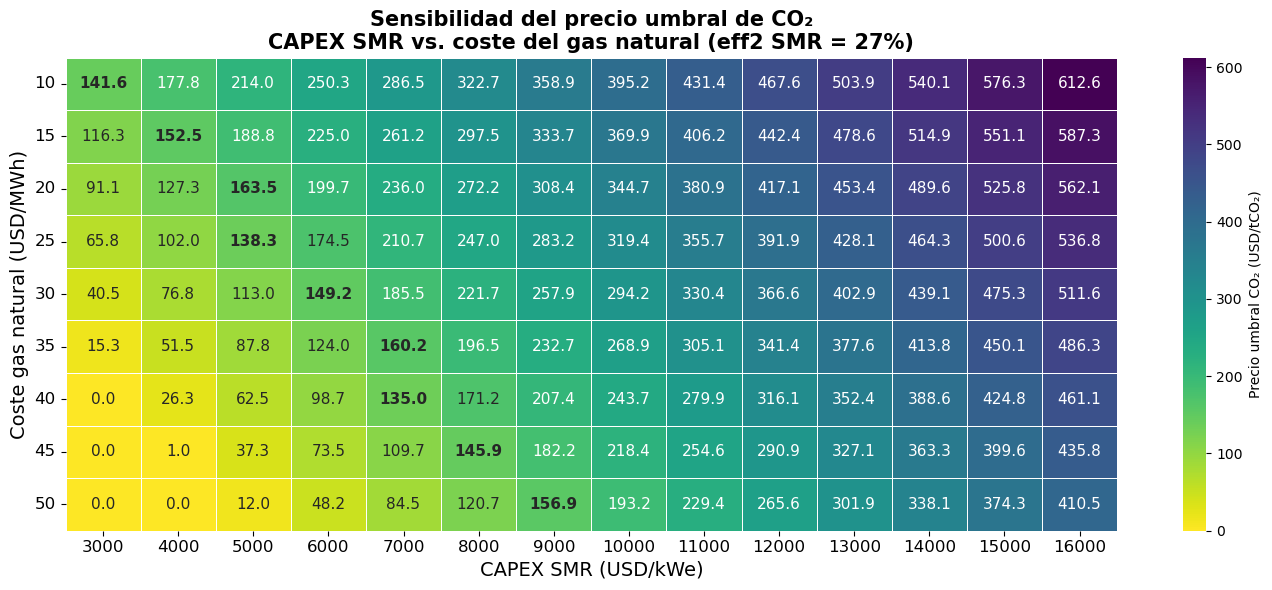

In [ ]:
plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    df_results,
    cmap="viridis_r",
    annot=True,
    fmt=".1f",
    annot_kws={"fontsize": 11},
    cbar_kws={"label": "Precio umbral CO₂ (USD/tCO₂)"},
    linecolor='white',
    linewidths=0.5
)
plt.xlabel("CAPEX SMR (USD/kWe)", fontsize=14)
plt.ylabel("Coste gas natural (USD/MWh)", fontsize=14)
plt.title("Sensibilidad del precio umbral de CO₂\nCAPEX SMR vs. coste del gas natural (eff2 SMR = 27%)",
          fontsize=15, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.yticks(rotation=0, fontsize=12)  # Etiquetas del eje y horizontales
plt.tight_layout()

# Poner en negrita los valores entre 135 y 170
for text in ax.texts:
    try:
        value = float(text.get_text())
        if 135 <= value <= 170:
            text.set_weight('bold')
    except ValueError:
        pass
# plt.savefig("HeatMap_Gas_capex.png", dpi=300, bbox_inches="tight")

plt.show()

## 6. Extras

### Umbral del CO2 implícito básico

In [ ]:
# ===================== PARÁMETROS DE SENSIBILIDAD Y COSTOS =====================
select_rate = cost.loc["SMR_CHP", "rate"]  # Parámetro de tasa de descuento

# Impuestos nucleares en el DataFrame de costos
cost["tax"] = cost["tax"].astype(float)  # Asegura tipo float
cost.loc["SMR_CHP", "tax"] = 16.31  # Impacto de impuestos, 16.31 // Fuente PWC

# ===================== ANUALIZACIÓN DE COSTOS DE INVERSIÓN =====================
lifetime = cost["lifetime"].values
annualized_inv = [
    packages.annualized(val, select_rate, lifetime[i]) * 1000
    for i, val in enumerate(cost["investment"].values)
]  # Factor 1000 para convertir a USD/MW/año
cost["annualized_investment"] = annualized_inv  # Añade columna al DataFrame

# ===================== FILTRADO DE RANGO TEMPORAL ==============================
start_time = "2023-01-01 00:00:00"  # Inicio de la simulación
# start_time = "2023-01-02 01:00:00"   # Rango corto para pruebas rápidas
# end_time = "2023-01-02 10:00:00"     # Rango corto para pruebas rápidas
end_time = "2023-12-31 23:00:00"     # Todo el año (8760 horas)
snapshots = pd.date_range(start_time, end_time, freq="h")
num_snapshots = len(snapshots)  # Número de horas simuladas

# ===================== PRECIO DE ELECTRICIDAD ================================
# Carga archivo de precios y lo indexa por fecha/hora
price_data = pd.read_csv('./ES_Price.csv')
price_data.index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="h")
filtered_prices = price_data.loc[start_time:end_time]

# ===================== DEMANDAS Y ENERGÍA TOTAL ==============================
heat_demand = 294  # MWth
electricity_demand = 135  # MWe
Heat_EnergyT = heat_demand * num_snapshots  # MWh_th totales
PowerT = (heat_demand + electricity_demand)
EnergyT = PowerT * num_snapshots  # MWh totales simulados
NGas_max = Heat_EnergyT / 0.33  # Máximo gas natural requerido

# ===================== CREACIÓN DE LA RED PYPSA ==============================
network = pypsa.Network()  # Crea objeto de red vacío
network.set_snapshots(snapshots)  # Define rango temporal

# ===================== DEFINICIÓN DE CARRIERS Y EMISIONES =====================
network.add("Carrier", "Gas",
            co2_emissions=cost.loc["Gas_CHP", "carbon_intensity"])  # tCO2/MWh_th
network.add("Carrier", "nuclear")
network.add("Carrier", "heat")       # Salida
network.add("Carrier", "electricity")  # Salida

# ===================== RESTRICCIÓN DE CO2 =====================================
CO2_reduction = 0.2  # Reducción del 80% para 2035
MaxCO2_possible = cost.loc["Gas_CHP", "carbon_intensity"] * NGas_max  # Máximo evitable
limit_CO2 = MaxCO2_possible * CO2_reduction  # Límite anual de emisiones
network.add("GlobalConstraint",
            "co2_limit",
            sense="<=",
            carrier_attribute="co2_emissions",
            constant=limit_CO2)

# ===================== BUSES PRINCIPALES Y CARGAS =============================
network.add("Bus", "Industry Electricity", carrier="electricity")
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=electricity_demand)
network.add("Bus", "Industry Heat", carrier="heat")
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=heat_demand)

# ===================== BUSES DE COMBUSTIBLE ===================================
network.add("Bus", "uranium_UO2", carrier="nuclear")
network.add("Bus", "Gas_Fuel_in", carrier="Gas")
network.add("Bus", "Spain_grid", carrier="electricity")

# ===================== ALMACENAMIENTOS (STORES) ===============================
network.add("Store", "Spain gas", bus="Gas_Fuel_in",
    e_initial=1e10,
    e_nom_extendable=True)
network.add("Store", "uranium", bus="uranium_UO2",
    e_initial=1e10,
    e_nom_extendable=True)
network.add("Store", "Spain grid", bus="Spain_grid",
    e_initial=1e10,
    e_nom_extendable=True)

# ===================== DUMP (VERTIDO DE EXCESOS) ==============================
network.add("Bus", "Heat Dump", carrier="heat")
network.add("Link", "Heat_Dump_Link",
    bus0="Industry Heat",
    bus1="Heat Dump",
    p_nom=1e10,
    capital_cost=1,
    marginal_cost=0.1,
    efficiency=1)
network.add("Store", "Heat_Dump_Store", bus="Heat Dump",
    e_initial=0,
    e_nom=1e100)

network.add("Bus", "Electricity Dump", carrier="electricity")
network.add("Link", "Electricity_Dump_Link",
    bus0="Industry Electricity",
    bus1="Electricity Dump",
    p_nom=1e10,
    capital_cost=1,
    marginal_cost=1,
    efficiency=1)
network.add("Store", "Electricity_Dump_Store", bus="Electricity Dump",
    e_initial=0,
    e_nom=1e100)

# ===================== ENLACES PRINCIPALES (LINKS) ============================
# Gas CHP
network.add("Link", "Link_Gas_CHP",
    bus0="Gas_Fuel_in",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    p_nom_min=0,
    p_nom_max=PowerT*3,
    p_nom_extendable=True,
    capital_cost=cost.loc["Gas_CHP", "annualized_investment"] + cost.loc["Gas_CHP", "FOM"] * 1000,
    marginal_cost=(cost.loc["Gas_CHP", "VOM"] + cost.loc["Gas_CHP", "fuel"] + cost.loc["Gas_CHP", "carbon_cost"] * cost.loc["Gas_CHP", "carbon_intensity"]),
    efficiency=cost.loc["Gas_CHP", "efficiency1"],
    efficiency2=cost.loc["Gas_CHP", "efficiency2"],
)
# SMR CHP
network.add("Link", "Link_SMR_CHP",
    bus0="uranium_UO2",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    p_nom_min=0,
    p_nom_max=PowerT*3,
    p_nom_extendable=True,
    capital_cost=(cost.loc["SMR_CHP", "annualized_investment"] + cost.loc["SMR_CHP", "FOM"] * 1000),
    marginal_cost=(cost.loc["SMR_CHP", "VOM"] + cost.loc["SMR_CHP", "fuel"]),
    # marginal_cost=cost_LCOE.loc["SMR_CHP","LCOE_Total"], # Alternativa
    efficiency=cost.loc["SMR_CHP", "efficiency1"],
    efficiency2=cost.loc["SMR_CHP", "efficiency2"],
)
# Red eléctrica española
network.add("Link", "Link_Spain_Grid",
    bus0="Spain_grid",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    p_nom=200,
    capital_cost=1,
    marginal_cost=filtered_prices['Price'],  # Precios horarios de 2023
    efficiency=1,
    efficiency2=0,
)

# ===================== OPTIMIZACIÓN Y RESULTADOS ==============================
network.optimize()

shadow_price = network.global_constraints.at["co2_limit", "mu"]
print(f"Shadow Price of Carbon: {shadow_price} USD/tCO2")


### LCOE basic

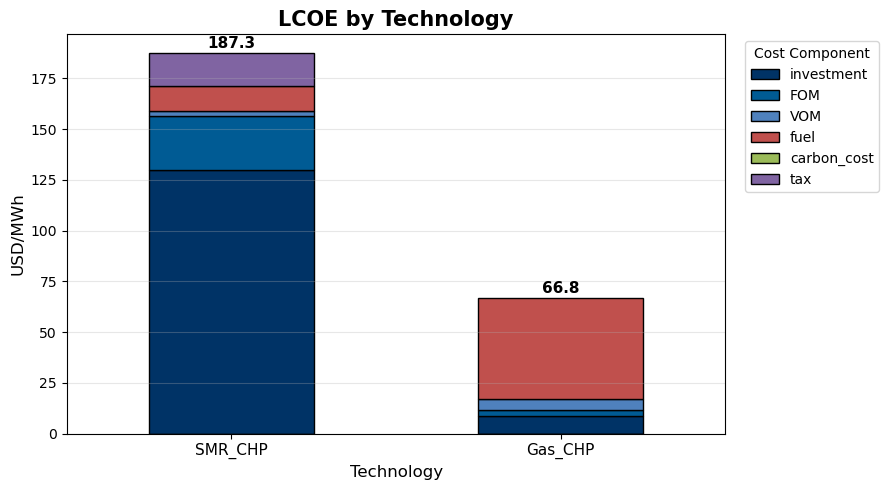

Barrido para hallar el umbral de coste del CO2 en el caso de generación eléctrica para 2035

El LCOE de Gas_CHP y SMR_CHP se igualan aproximadamente en carbon_cost = 604.04 USD/tCO2 (LCOE ≈ 186.44 USD/MWh)


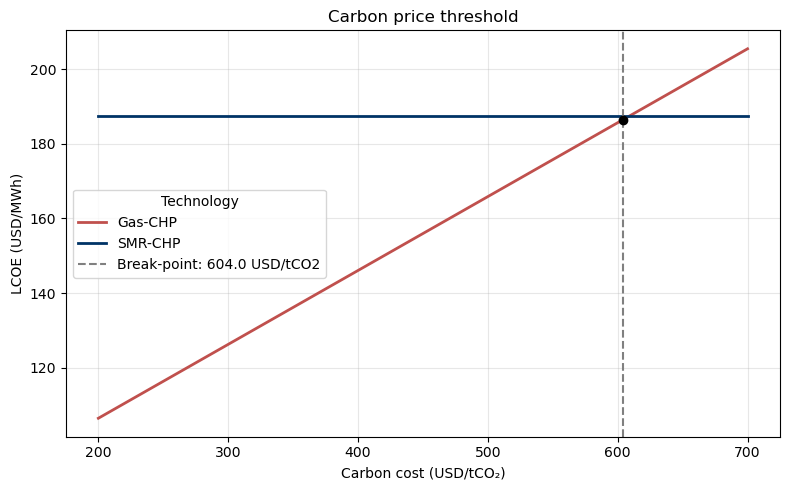

In [26]:
# Barrido de carbon_cost para igualar LCOE de Gas_CHP y SMR_CHP
# Comienza el barrido en 200 USD/tCO2
carbon_cost_range = np.linspace(200, 700, 100)
lcoe_gas = []
lcoe_smr = []

# Soluciona el warning: fuerza el tipo float en la columna carbon_cost
cost["carbon_cost"] = cost["carbon_cost"].astype(float)

for cc in carbon_cost_range:
    cost.loc["Gas_CHP", "carbon_cost"] = float(cc)
    # Recalcula el LCOE para cada valor de carbon_cost
    df_tmp = pd.DataFrame()
    for tech in techs:
        df_tmp = pd.concat([df_tmp, packages.LCOE(tech, cost, tech)])
    lcoe_gas.append(df_tmp.loc["Gas_CHP"].sum())
    lcoe_smr.append(df_tmp.loc["SMR_CHP"].sum())

lcoe_gas = np.array(lcoe_gas)
lcoe_smr = np.array(lcoe_smr)

# Encuentra el valor de carbon_cost donde se cruzan los LCOE
idx_cross = np.argwhere(np.diff(np.sign(lcoe_gas - lcoe_smr)) != 0)
if len(idx_cross) > 0:
    idx_cross = idx_cross[0][0]
    cc_cross = carbon_cost_range[idx_cross]
    lcoe_cross = lcoe_gas[idx_cross]
    print(f"El LCOE de Gas_CHP y SMR_CHP se igualan aproximadamente en carbon_cost = {cc_cross:.2f} USD/tCO2 (LCOE ≈ {lcoe_cross:.2f} USD/MWh)")
else:
    print("No se encontró cruce en el rango analizado.")

# Gráfica de la evolución del LCOE total en función del carbon_cost
fig = plt.figure(figsize=(8,5))
plt.plot(carbon_cost_range, lcoe_gas, label="Gas-CHP", color="#C0504D", linewidth=2)
plt.plot(carbon_cost_range, lcoe_smr, label="SMR-CHP", color="#003366", linewidth=2)
if isinstance(idx_cross, (np.ndarray, list)):
    has_cross = len(idx_cross) > 0
else:
    has_cross = idx_cross is not None

if has_cross:
    plt.axvline(cc_cross, color="gray", linestyle="--", label=f"Cruce: {cc_cross:.1f} USD/tCO2")
    plt.scatter([cc_cross], [lcoe_cross], color="black", zorder=5)

plt.title("Carbon price threshold")  # Título añadido
plt.xlabel("Carbon cost (USD/tCO₂)")  # Eje horizontal con unidades
plt.ylabel("LCOE (USD/MWh)")          # Eje vertical con unidades
plt.legend(["Gas-CHP", "SMR-CHP", f"Break-point: {cc_cross:.1f} USD/tCO2"], title="Technology")
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("CO2_umbral.png", dpi=300, bbox_inches="tight")  # Guardar en PNG (alta resolución, opcional)
plt.show()

### 2.2 Debug del método explícito

In [ ]:
# Elige las dos tuplas que quieres comparar
tupla1 = (27.299999999999997, 50)
tupla2 = (33.599999999999994, 50)

df1 = resultados_potencias[tupla1]
df2 = resultados_potencias[tupla2]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Solo graficar la potencia del SMR (Link_SMR_CHP) con alta precisión
axes[0].plot(df1.index, df1["Link_SMR_CHP"], label="SMR", color="tab:blue")
axes[0].set_title(f"Potencia SMR (eff2={tupla1[0]:.2f}%, price={tupla1[1]})")
axes[0].set_ylabel("Potencia SMR (MW)")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.6f}'))

axes[1].plot(df2.index, df2["Link_SMR_CHP"], label="SMR", color="tab:orange")
axes[1].set_title(f"Potencia SMR (eff2={tupla2[0]:.2f}%, price={tupla2[1]})")
axes[1].set_xlabel("Snapshot")
axes[1].set_ylabel("Potencia SMR (MW)")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.6f}'))

plt.tight_layout()
plt.show()

# Redondea a 6 decimales antes de contar valores únicos
varia1 = df1["Link_SMR_CHP"].round(6).nunique() > 1
varia2 = df2["Link_SMR_CHP"].round(6).nunique() > 1

if varia1:
    print(f"La potencia del SMR varía a lo largo de los snapshots para eff2={tupla1[0]:.2f}%, price={tupla1[1]}")
else:
    print(f"La potencia del SMR es constante para eff2={tupla1[0]:.2f}%, price={tupla1[1]}")

if varia2:
    print(f"La potencia del SMR varía a lo largo de los snapshots para eff2={tupla2[0]:.2f}%, price={tupla2[1]}")
else:
    print(f"La potencia del SMR es constante para eff2={tupla2[0]:.2f}%, price={tupla2[1]}")

# Calcular la variación de la potencia SMR a lo largo de los snapshots
def print_variacion(df, tupla):
    potencia = df["Link_SMR_CHP"]
    min_p = potencia.min()
    max_p = potencia.max()
    std_p = potencia.std()
    rango = max_p - min_p
    print(f"Para eff2={tupla[0]:.2f}%, price={tupla[1]}:")
    print(f"  Potencia mínima: {min_p:.6f} MW")
    print(f"  Potencia máxima: {max_p:.6f} MW")
    print(f"  Rango (max-min): {rango:.6f} MW")
    print(f"  Desviación estándar: {std_p:.6f} MW")

print_variacion(df1, tupla1)
print_variacion(df2, tupla2)